### Notebook 2: Existing template analysis

In some cases, we have templates that exist from previous work.  We may wish to look at these templates to decide which stations to use. Here we'll have a look at some existing template's from Bostock et al (2012)'s work in Cascadia.

In [1]:
# let's import some relevant packages
import numpy as np
import obspy
import matplotlib.pyplot as plt
import os

import os,sys
sys.path.append(os.path.join(os.environ['PYFILES']))
import LFEAnalysis as lfeanalysis

### 1. Initialise an analysis object

As before, we'll initialise an lfeanalyse object to contain the data and do the analysis.  

In [2]:
# if your data will not be in $DATA/LFEAnalysis, specify the data directory to use
data_directory=os.path.join(os.environ['DATA'],'LFEAnalysis')

# now we can create an analysis object
# we choose a particular family: here #74
lf=lfeanalysis.lfeanalyse(fnum=74,data_directory=data_directory,region='Cascadia')

print('We are analysing LFE family {:d} in {:s}'.format(lf.fnum,lf.region))

We are analysing LFE family 74 in Cascadia


### 3. Read in the list of detections and the existing templates

We can now read in the times of detections in this family in an LFE catalogue of interest.  This loading also loads the existing templates.

In [3]:
# pick the catalogue to use
# some catalogues are chosen by default for the region of interest
print('By default for {:s}, we would use the {:s} catalogue'.format(lf.region,lf.catalog))

# but we can specify another if we like
# here we use the catalog developed by Bostock et al, 2012
lf.catalog='Bostock'

print('We are now are using the {:s} catalogue'.format(lf.catalog))

By default for Cascadia, we would use the Bostock catalogue
We are now are using the Bostock catalogue


In [4]:
# now read the detection times and any existing templates
lf.read_detection_info()

### 4. Note the existing templates

These are saved as obspy Streams in lf.sttemp.  

In [5]:
# we may also have existing stacks of the LFEs from previous work
# these are read in with read_detection_info and saved as obspy traces
# we'll have a look at them in the next notebook
lf.sttemp

177 Trace(s) in Stream:

.B012..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:59.975000Z | 40.0 Hz, 2400 samples
...
(175 other traces)
...
.B004..Z | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:59.975000Z | 40.0 Hz, 2400 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

The start times are irrelevant; it's just a time series.  The time spacing is correct though, as is the station.  For Bostock et al's catalogue, the channels are just given as E, N, or Z, and these are stacks of velocity.  The units are generally irrelevant, as many researchers normalise individual seismograms before averaging them in a stack.

In [6]:
lf.sttemp[0].stats

         network: 
         station: B012
        location: 
         channel: E
       starttime: 1970-01-01T00:00:00.000000Z
         endtime: 1970-01-01T00:00:59.975000Z
   sampling_rate: 40.0
           delta: 0.025
            npts: 2400
           calib: 1.0

### 5. Identify the arrival times

We may want to identify the arrival times in the a stack of LFE signals.  The function lf.pick_templates does that by identifying the few-second-long interval with the maximum power, where power is summed over the two horizontal components ('E' and 'N').  All three components are assigned the same arrival time. The interval length is specified by wlen, measured in seconds.  The beginnings and ends of the windows with the maximum power in each trace "tr are saved as "tr.stats.t0" and "tr.stats.t1", respectively.

Many of the recording stations will have poor stacks; they may be too far away to record anything useful.  So we'll also compute the signal to noise power ratio for each station.  This is the ratio of the power in the signal window to the window immediately preceding it.

In [7]:
# if a previous study has already made stacks of LFEs: templates,
# let's identify the arrival times and compute the signal to noise power ratios in those stacks
lf.pick_templates(wlen=5,minsnr=0.)

In [8]:
# the signal to noise power ratios are saved in a dictionary
print(lf.temp_snrs)

{'A04A': 5.835845450654718, 'A04D': 5.5235563782208725, 'B001': 2.096527009389917, 'B003': 8.38780346336646, 'B004': 6.066802531267702, 'B007': 13.655727317038611, 'B011': 47.56714694878726, 'B012': 2.0572412700406018, 'B04A': 1.9286504674680123, 'B926': 121.58119985218235, 'B927': 5.334588485828302, 'B928': 6.555337276695893, 'BIB': nan, 'BMSB': 2.091556613847129, 'BPCB': 31.334153214496176, 'CPLB': 1.7905077126598437, 'ENGB': 1.9083591841793002, 'GHNB': 4.784930599183665, 'GLBC': 6.3740600942949595, 'GOBB': nan, 'GOWB': 82.24148895823787, 'JRBC': 15.961163899191089, 'KELB': 15.898569889936066, 'KHVB': 28.84447516395185, 'KLNB': 33.597010095794055, 'LCBC': 2.170282560042523, 'LOP3': 1.230037255577648, 'LRIV': 7.283641045533715, 'LZB': 76.17420287635889, 'MGB': 36.175717489469065, 'MGCB': 57.41064586535943, 'NLLB': 50.39382428597287, 'OPC': 1.807880357123905, 'OZB': 4.998336824484352, 'PFB': 38.38005184342541, 'PGC': 55.19015960828753, 'PHYB': 25.928494785250976, 'SHB': 21.718902644324

Station B011 looks alright


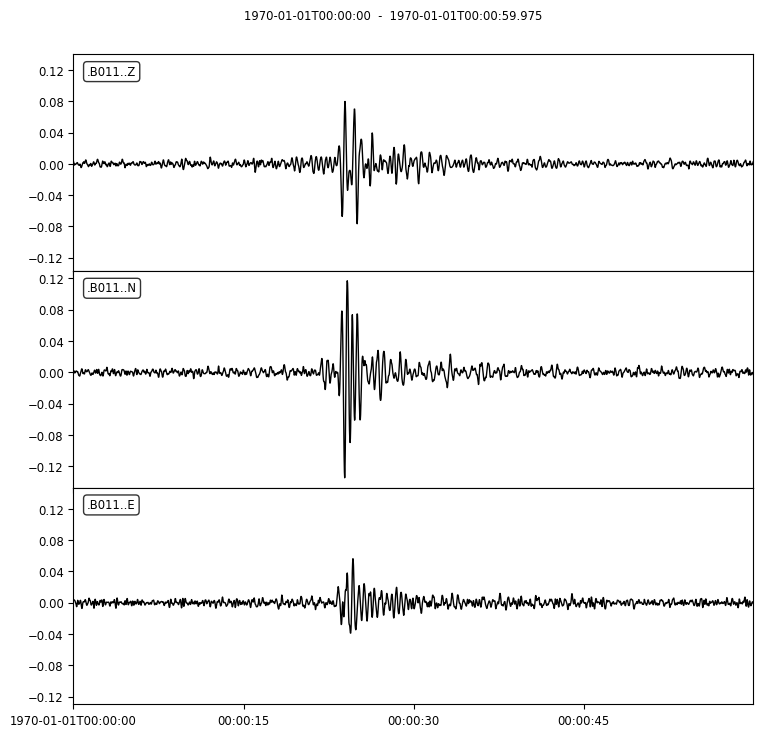

In [9]:
# let's have a look at one of the templates with large SNR
ix=np.where(np.array(list(lf.temp_snrs.values()))>20)[0]
stn=list(lf.temp_snrs.keys())[ix[0]]
print('Station {:s} looks alright'.format(stn))

# grab out and plot the data
st=lf.sttemp.select(station=stn)
st.plot();

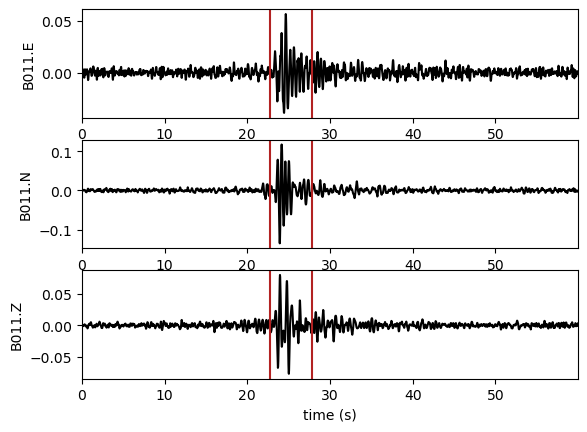

In [10]:
# and check the arrival time picks
for k in range(0,len(st)):
    ph=plt.subplot(len(st),1,k+1)
    ph.plot(st[k].times(),st[k].data,color='k')
    ph.axvline(st[k].stats.t0,color='firebrick')
    ph.axvline(st[k].stats.t1,color='firebrick')
    ph.set_xlim([np.min(st[k].times()),np.max(st[k].times())])
    ph.set_ylabel('.'.join([st[k].stats.station,st[k].stats.channel]))
ph.set_xlabel('time (s)');

### 6. Identify stations with high SNR ratios

We may want to only analyse data at stations with signal to noise power ratios above a certain threshold.  You can do this by looking at the values in the dictionary lf.temp_snrs.  Or the function lf.pick_templates will collect the stations that have power ratios above a threshold value "minsnr."  These stations are saves in an array lf.stns.  The power computations are done by summing the power on the E and N channels.

In [11]:
# let's identify the arrival times and compute the signal to noise power ratios in those stacks
lf.pick_templates(wlen=5,minsnr=10.)

In [12]:
# and the stations that have signal to noise ratios bigger than minsnr input above are listed in lf.stns
lf.stns

array(['B007', 'B011', 'B926', 'BPCB', 'GOWB', 'JRBC', 'KELB', 'KHVB',
       'KLNB', 'LZB', 'MGB', 'MGCB', 'NLLB', 'PFB', 'PGC', 'PHYB', 'SHB',
       'SHDB', 'SILB', 'SNB', 'SOK1', 'SOK2', 'SOK4', 'SOK5', 'SOKB',
       'SSIB', 'TSJB', 'TWBB', 'TWGB', 'TWKB', 'YOUB'], dtype='<U4')